# Create multi-wavelength datasets

As the name indicactes, this scipt is used to creat the multiwavelength datasets.

In [1]:
import os
import shutil
from datetime import datetime, timedelta
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
from skimage.transform import resize

In [5]:
# Paths
folder_304_mask = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Home_made_filament_dataset\masks"
folder_193_mask = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193_CLEANED\labelsTr"
folder_171_mask = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(spoca)\masks"


folder_304_sun = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Home_made_filament_dataset\304_imgs"
folder_193_sun = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193_CLEANED\imagesTr"
folder_171_sun = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(spoca)\imgs"

target_304_sun = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\304_all_sun"
target_193_sun = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\193_all_sun"
target_171_sun = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\171_all_sun"

target_304_mask = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\304_all_mask"
target_193_mask = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\193_all_mask"
target_171_mask = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\171_all_mask"

This create folders, and prepare the functions and the list of the files

In [ ]:

os.makedirs(target_304_sun, exist_ok=True)
os.makedirs(target_193_sun, exist_ok=True)
os.makedirs(target_171_sun, exist_ok=True)

os.makedirs(target_304_mask, exist_ok=True)
os.makedirs(target_193_mask, exist_ok=True)
os.makedirs(target_171_mask, exist_ok=True)

# Extract timestamp and convert to datetime object
def extract_timestamp(name: str):
    name_no_ext = os.path.splitext(os.path.basename(name))[0]  # remove .png
    parts = name_no_ext.split("__")
    if len(parts) >= 2:
        ts_str = parts[0] + "__" + parts[1]  # "YYYY_MM_DD__HH_MM_SS_ff"
        # Convert to datetime
        try:
            dt = datetime.strptime(ts_str, "%Y_%m_%d__%H_%M_%S_%f")
        except ValueError:
            # If ff has only 2 digits, multiply by 10000 to get microseconds
            date_part, time_part = ts_str.split("__")
            h, m, s, ff = map(int, time_part.split("_"))
            micro = ff * 10000  # 2 digits -> 6 digits
            dt = datetime(dt.year, dt.month, dt.day, h, m, s, micro)
        return dt
    else:
        return None

# Find closest datetime
from datetime import timedelta

def closest_ts(ts, ts_list, max_diff_minutes=20):
    min_diff = timedelta.max  # initialement très grand
    best = None
    for f, t in ts_list:
        if t is None:
            continue
        diff = abs(ts - t)
        if diff < min_diff:
            min_diff = diff
            best = t
    if min_diff > timedelta(minutes=max_diff_minutes):
        #print(f" Aucun timestamp proche trouvé pour {ts}")
        return None
    return best

# Build lists of files  and the list of timestamps
files_304 = [f for f in os.listdir(folder_304_sun) if f.endswith(".png")]
files_193 = [f for f in os.listdir(folder_193_sun) if f.endswith(".png")]
files_171 = [f for f in os.listdir(folder_171_sun) if f.endswith(".png")]

ts_files_193 = [(f, extract_timestamp(f)) for f in files_193 if extract_timestamp(f) is not None]
ts_files_171 = [(f, extract_timestamp(f)) for f in files_171 if extract_timestamp(f) is not None]

Find all the samples with the corresponding timestamps in the list of files you choose and stores them.

In [12]:
# Process 304 images
for f304 in os.listdir(folder_304_mask):
    ts = extract_timestamp(f304)

    # 193
    closest_193_ts = closest_ts(ts, ts_files_193)
    closest_171_ts = closest_ts(ts, ts_files_171)

    if closest_193_ts == None or closest_171_ts == None:
        print(f"{ts}: Couldn't find a match for all channels")
    else:
        for f, t in ts_files_193:
            if t == closest_193_ts:
                shutil.copy2(os.path.join(folder_193_sun, f), target_193_sun)
                shutil.copy2(os.path.join(folder_193_mask, f), target_193_mask)
                
        for f, t in ts_files_171:
            if t == closest_171_ts:
                shutil.copy2(os.path.join(folder_171_sun, f), target_171_sun)
                shutil.copy2(os.path.join(folder_171_mask, f), target_171_mask)
        shutil.copy2(os.path.join(folder_304_sun, f304), target_304_sun)
        shutil.copy2(os.path.join(folder_304_mask, f304), target_304_mask)

print("Copying done!")

2013-08-02 14:36:07.120000: Couldn't find a match for all channels
2013-08-05 22:48:07.120000: Couldn't find a match for all channels
2014-01-09 23:00:07.140000: Couldn't find a match for all channels
2014-01-11 23:00:07.140000: Couldn't find a match for all channels
2014-01-12 23:00:07.120000: Couldn't find a match for all channels
2014-02-05 23:00:07.130000: Couldn't find a match for all channels
2014-02-06 23:00:07.120000: Couldn't find a match for all channels
2014-04-03 23:00:07.120000: Couldn't find a match for all channels
2014-07-26 23:00:07.140000: Couldn't find a match for all channels
Copying done!


In [15]:
num_files_171_sun = [f for f in os.listdir(target_171_sun) if os.path.isfile(os.path.join(target_171_sun, f))]
num_files_193_sun = [f for f in os.listdir(target_193_sun) if os.path.isfile(os.path.join(target_193_sun, f))]
num_files_304_sun = [f for f in os.listdir(target_304_sun) if os.path.isfile(os.path.join(target_304_sun, f))]
num_files_171_mask = [f for f in os.listdir(target_171_mask) if os.path.isfile(os.path.join(target_171_mask, f))]
num_files_193_mask = [f for f in os.listdir(target_193_mask) if os.path.isfile(os.path.join(target_193_mask, f))]
num_files_304_mask = [f for f in os.listdir(target_304_mask) if os.path.isfile(os.path.join(target_304_mask, f))]
print(f"Nombre de fichiers dans 171 mask: {len(num_files_171_mask)}")
print(f"Nombre de fichiers dans 193 mask: {len(num_files_193_mask)}")
print(f"Nombre de fichiers dans 304 mask: {len(num_files_304_mask)}")
print(f"Nombre de fichiers dans 171 sun: {len(num_files_171_sun)}")
print(f"Nombre de fichiers dans 193 sun: {len(num_files_193_sun)}")
print(f"Nombre de fichiers dans 304 sun: {len(num_files_304_sun)}")

Nombre de fichiers dans 171 mask: 0
Nombre de fichiers dans 193 mask: 0
Nombre de fichiers dans 304 mask: 0
Nombre de fichiers dans 171 sun: 0
Nombre de fichiers dans 193 sun: 0
Nombre de fichiers dans 304 sun: 0


Roatation of the 304 files and masks of the training set AFTER separating into training and test set. The seperation is done manually.

In [14]:
rot_304_sun = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTr_png\304"
rot_304_mask = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTr_png\304"
angles = [90, 180, 270]
list_of_folder_to_rotate = [rot_304_sun, rot_304_mask]
   
for to_rotate in list_of_folder_to_rotate:
    for filename in os.listdir(to_rotate):
        if filename.lower().endswith(".png"):
            img_path = os.path.join(to_rotate, filename)
            img = Image.open(img_path)
            
            # Get base filename without extension
            base_name = os.path.splitext(filename)[0]
            
            # Rotate and save each version
            for angle in angles:
                rotated = img.rotate(angle, expand=True)
                rotated_filename = f"{base_name}_r{angle}.png"
                rotated.save(os.path.join(to_rotate, rotated_filename))

print("All images rotated and saved!")


All images rotated and saved!


4) Convert all into nii.gz and transform all masks into 1

#### images -Tr/Ts

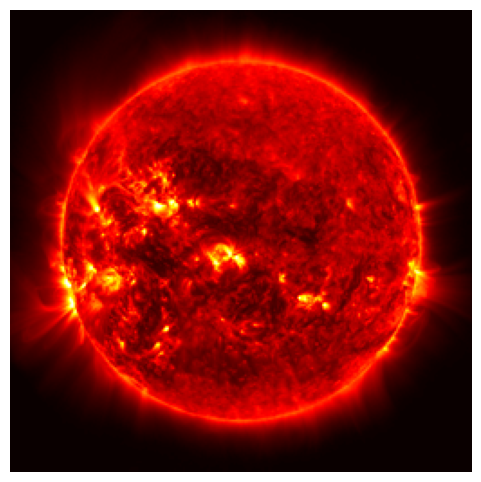

17


In [ ]:
## For Training set
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTr_png\171"
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTr_png\193"
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTr_png\304"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\imagesTr"


## For Test set
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTs_png\171"
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTs_png\193"
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTs_png\304"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\imagesTs"

#chan_wav = "0000"       # 171 = 0000, 193 = 0001, 304 = 0002


input_dir = r"REEEEAAAD, dont forget the percentile_top_limite if needed"
output_dir = r"REEEEAAAD, dont forget the percentile_top_limite if needed"
chan_wav = r"Still read mate"

# # Exemple
# input_dir = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\imagesTs_png\171"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\imagesTs"
# chan_wav = r"0000"       # 171 = 0000, 193 = 0001, 304 = 0002


png_files = [f for f in os.listdir(input_dir) if f.lower().endswith(".png")]

for idx, filename in enumerate(png_files):
    # Load PNG as grayscale
    img_path = os.path.join(input_dir, filename)
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)
    if img_array.shape != (256,256):
        print(f"resizing of image: {img_path}")
        resized_img = resize(img_array, (256, 256), order=3, preserve_range=True, anti_aliasing=True)
    else:
        resized_img = img_array
    array_closest_img = [resized_img]
    #norm_img = normalizing_data(array_closest_img)
    #finale_img = crop_data(array_closest_img) #norm_img
    #finale_img = finale_img[0]


    
    #sitk_img = sitk.GetImageFromArray(finale_img)
    sitk_img = sitk.GetImageFromArray(array_closest_img[0])
    # Zero-padded case ID
    case_id = str(idx).zfill(4)  # 0000, 0001, 0002, ...
    output_name = f"case_{case_id}_{chan_wav}.nii.gz"

    # Full output path
    output_path = os.path.join(output_dir, output_name)

    # Checking
    if case_id == "0000":
        plt.figure(figsize=(6,6))
        #plt.imshow(finale_img, cmap="hot")
        plt.imshow(array_closest_img[0], cmap="hot")
        
        plt.axis("off")
        plt.show()
        

    # Save as NIfTI
    sitk.WriteImage(sitk_img, output_path)
print(idx)

#### labels -Tr/Ts

In [24]:
import numpy as np

## For Training set
# folder_mask_AR = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTr_png\171"
# folder_mask_CH = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTr_png\193"
# folder_mask_FL = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTr_png\304"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\labelsTr"


## For Test set
# folder_mask_AR = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\171"
# folder_mask_CH = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\193"
# folder_mask_FL = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\304"
# output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\labelsTs"



folder_mask_AR = r"REEEEAAAD"
folder_mask_CH = r"REEEEAAAD"
folder_mask_FL = r"REEEEAAAD"
output_dir = r"REEEEAAAD"

folder_mask_AR = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\171"
folder_mask_CH = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\193"
folder_mask_FL = r"C:\Users\User\Master_physics\Master_Thesis\addittional_dataset\Dataset668_SDO_AIA\labelsTs_png\304"
output_dir = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\labelsTs"


files_mask1 = sorted([f for f in os.listdir(folder_mask_AR) if f.lower().endswith(".png")])
files_mask2 = sorted([f for f in os.listdir(folder_mask_CH) if f.lower().endswith(".png")])
files_mask3 = sorted([f for f in os.listdir(folder_mask_FL) if f.lower().endswith(".png")])

assert len(files_mask1) == len(files_mask2) == len(files_mask3), "All folders must have the same number of files"

for idx, (f1, f2, f3) in enumerate(zip(files_mask1, files_mask2, files_mask3)):
    mask1 = (np.array(Image.open(os.path.join(folder_mask_AR, f1)).convert("L")) > 0).astype(np.uint8)
    mask2 = (np.array(Image.open(os.path.join(folder_mask_CH, f2)).convert("L")) > 0).astype(np.uint8)
    mask3 = (np.array(Image.open(os.path.join(folder_mask_FL, f3)).convert("L")) > 0).astype(np.uint8)

    combined_mask = np.zeros_like(mask1, dtype=np.uint16)
    combined_mask += mask1.astype(np.uint16) * 1
    combined_mask += mask2.astype(np.uint16) * 2
    combined_mask += mask3.astype(np.uint16) * 4

    sitk_img = sitk.GetImageFromArray(combined_mask)
    case_id = str(idx).zfill(4)  # 0000, 0001, ...
    output_name = f"case_{case_id}.nii.gz"
    sitk.WriteImage(sitk_img, os.path.join(output_dir, output_name))

print(f"Combined {len(files_mask1)} masks and saved to {output_dir}")


# Now combined_mask values:
# 0 = background            
# 1 = AR
# 2 = CH
# 3 = AR+CH
# 4 = FL
# 5 = AR+FL
# 6 = CH+FL
# 7 = AR+CH+FL

Combined 18 masks and saved to C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\labelsTs


display of a multi-label mask

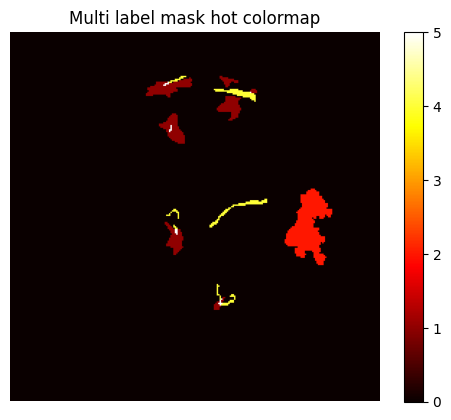

In [34]:
import nibabel as nib
import matplotlib.pyplot as plt

# Path to your file
path = r"C:\Users\User\nnUNet\nnUNet_raw\Dataset668_SDO_AIA\labelsTs\case_0017.nii.gz"

# Load NIfTI file
nii = nib.load(path)
data = nii.get_fdata()

# If it's 3D, display the middle slice
if data.ndim == 3:
    slice_index = data.shape[2] // 2
    img = data[:, :, slice_index]
else:
    img = data

# Plot with hot colormap
plt.imshow(img, cmap="hot")
plt.colorbar()
plt.title("Multi label mask hot colormap")
plt.axis("off")
plt.show()

### Code to overright the validation split of nnUNet to create a temporal split

In [44]:
import json
import math

def create_chronological_5fold(total_cases, output_path="splits_final.json"):
    
    # Create case IDs
    cases = [f"case_{i:04d}" for i in range(total_cases)]
    
    fold_size = math.ceil(total_cases * 0.2)  # ~20%
    
    splits = []
    
    for fold in range(5):
        
        # Compute validation block (starting from the end)
        start = total_cases - (fold + 1) * fold_size
        end = total_cases - fold * fold_size
        
        # Clamp to valid range
        start = max(start, 0)
        end = min(end, total_cases)
        
        val_cases = cases[start:end]
        train_cases = cases[:start] + cases[end:]
        
        splits.append({
            "train": train_cases,
            "val": val_cases
        })
    
    # Save JSON
    with open(output_path, "w") as f:
        json.dump(splits, f, indent=4)
    
    print(f"Created 5-fold chronological split.")
    print(f"Total cases: {total_cases}")
    print(f"Validation size per fold: ~{fold_size}")
    print(f"Saved to: {output_path}")


# Example usage:
create_chronological_5fold(total_cases=4140)

Created 5-fold chronological split.
Total cases: 4140
Validation size per fold: ~828
Saved to: splits_final.json
